<a href="https://colab.research.google.com/github/likith1525/ExcelR-data-science-assignments/blob/main/Codes/15Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Clustering assignment**

In [ ]:
import pandas as pd
import numpy as np

#**EDA**

In [ ]:
df = pd.read_excel("/content/EastWestAirlines.xlsx")

In [ ]:
df.head()

,East-West Airlines is trying to learn more about its customers. Key issues are their,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,"flying patterns, earning and use of frequent f...",NaN,NaN,NaN,NaN
1,card. The task is to identify customer segmen...,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,Source: Based upon real business data; company...,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 5 columns):
 #   Column                                                                                 Non-Null Count  Dtype 
---  ------                                                                                 --------------  ----- 
 0   East-West Airlines is trying to learn more about its customers.  Key issues are their  18 non-null     object
 1   Unnamed: 1                                                                             13 non-null     object
 2   Unnamed: 2                                                                             6 non-null      object
 3   Unnamed: 3                                                                             13 non-null     object
 4   Unnamed: 4                                                                             18 non-null     object
dtypes: object(5)
memory usage: 1.1+ KB


In [ ]:
df.describe()

,East-West Airlines is trying to learn more about its customers. Key issues are their,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,18,13,6,13,18
unique,18,3,3,3,18
top,"flying patterns, earning and use of frequent f...",NUMBER,1,Raw,Description
freq,1,9,3,9,1


In [ ]:
df.shape

(26, 5)

In [ ]:
df.head()

,East-West Airlines is trying to learn more about its customers. Key issues are their,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
8,Field Name,Data Type,Max Data Length,Raw Data or Telcom Created Field?,Description
10,Balance,NUMBER,8,Raw,Number of miles eligible for award travel
11,Qual_miles,NUMBER,8,Raw,Number of miles counted as qualifying for Topf...
12,cc1_miles,CHAR,1,Raw,Number of miles earned with freq. flyer credit...
13,cc2_miles,CHAR,1,Raw,Number of miles earned with Rewards credit car...


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans,DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings("ignore")

Dataset Shape: (3999, 12)

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


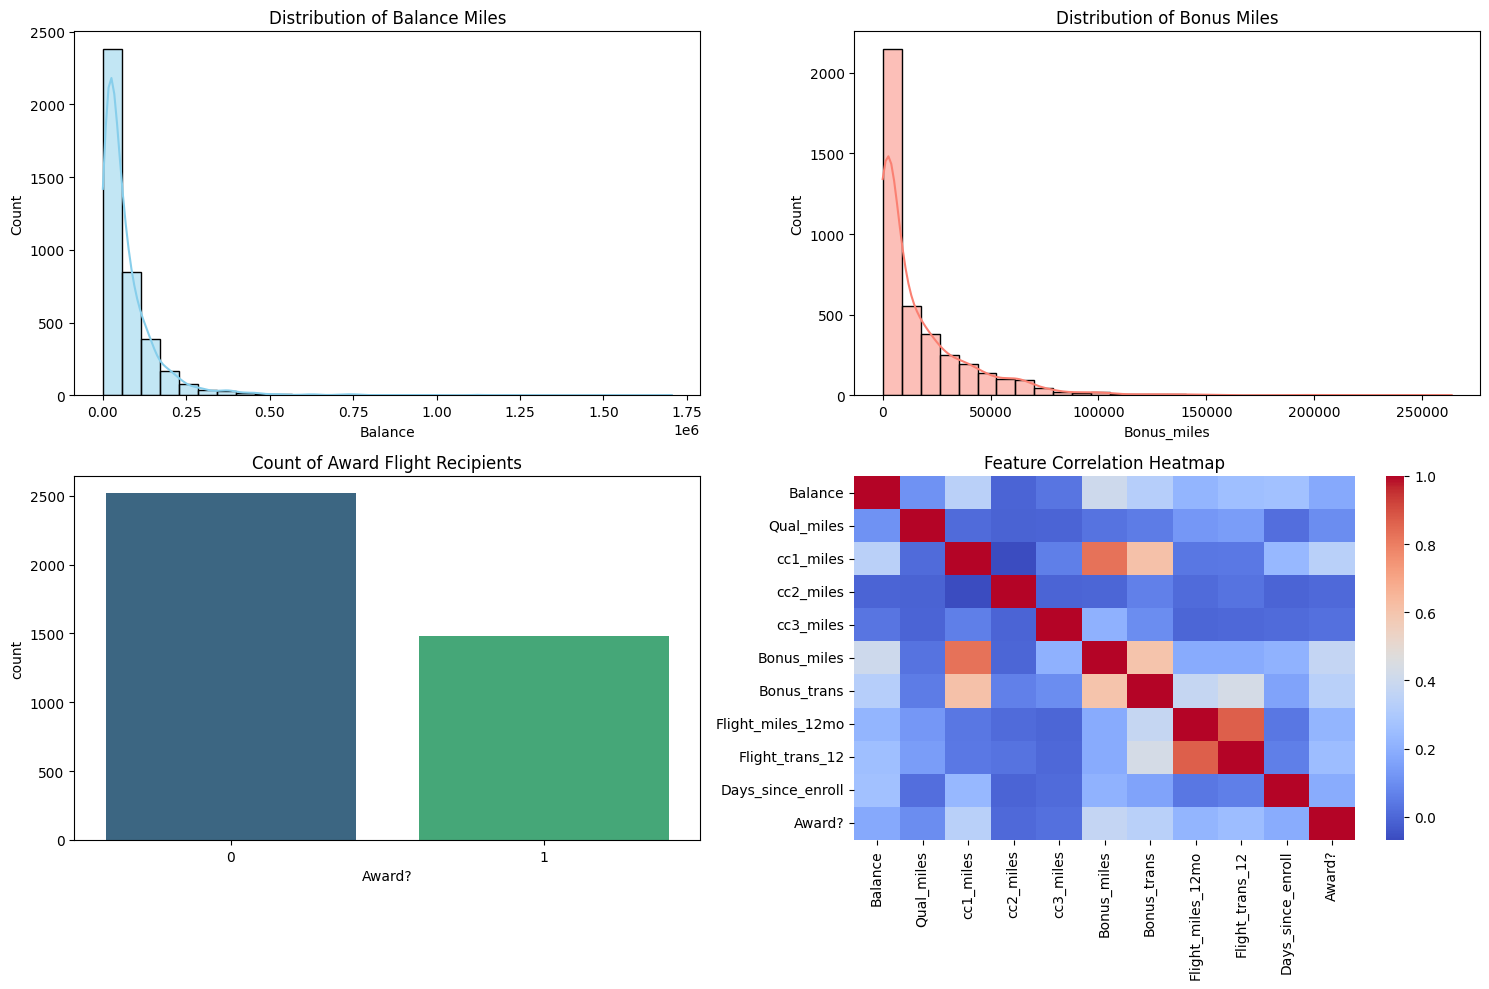

In [ ]:
# Load the Dataset

df = pd.read_excel('EastWestAirlines.xlsx', sheet_name='data')

# Basic Information
print("Dataset Shape:", df.shape)
print("\n--- Data Info ---")
df.info()

# Handle Missing Values & Drop ID
df = df.dropna() # Assuming we drop NAs, or you can use imputation
if 'ID#' in df.columns:
    df = df.drop('ID#', axis=1)

# Exploratory Data Analysis (EDA)
plt.figure(figsize=(15, 10))

# Plotting distributions of key features
plt.subplot(2, 2, 1)
sns.histplot(df['Balance'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Balance Miles')

plt.subplot(2, 2, 2)
sns.histplot(df['Bonus_miles'], bins=30, kde=True, color='salmon')
plt.title('Distribution of Bonus Miles')

plt.subplot(2, 2, 3)
sns.countplot(x='Award?', data=df, palette='viridis')
plt.title('Count of Award Flight Recipients')

plt.subplot(2, 2, 4)
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

# 5. Feature Scaling
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

#EDA INSIGHTS

* Right-skewness: The distribution plot reveals that features like `Balance` and `Bonus_miles` are highly right-skewed.A majority of customers have a lower balance ,while a few "WHALE" customers have massive balance.
* Correlation: The heatmap show strong correlation between flight transactions (`Flight_trans_12`) and flight miles (`Flight_miles_12mo`),as well as between bous miles ans bonus transactions,which is logically consistent.

# Implementing K-Means Clustering

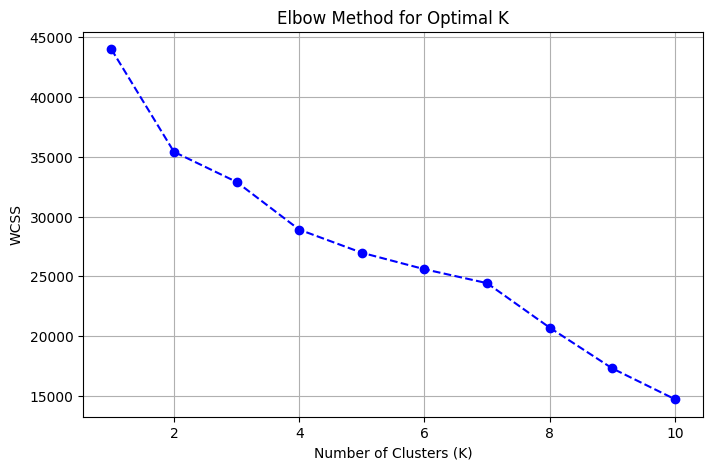

K-Means Silhouette Score (K=4): 0.1907


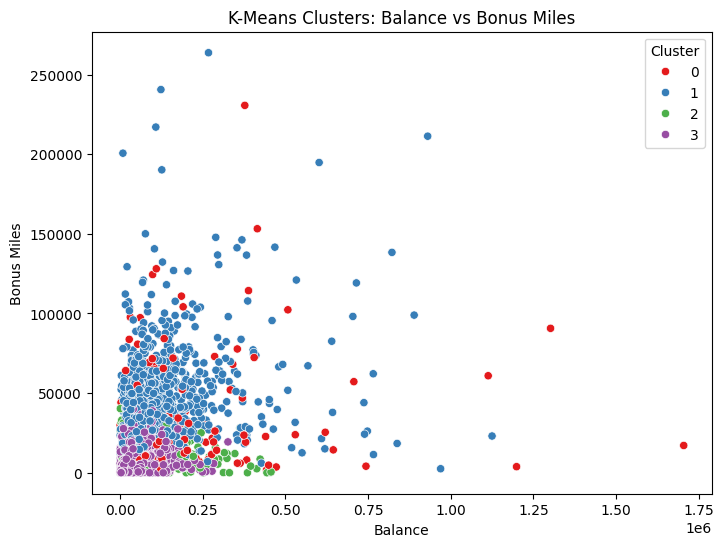

In [ ]:
# 1. Finding optimal K using the Elbow Method
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# Apply K-Means with optimal K (Assuming K=4 based on a typical elbow)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
kmeans_clusters = kmeans.fit_predict(df_scaled)

# Add cluster labels to the original dataframe
df['KMeans_Cluster'] = kmeans_clusters

# K-Means Silhouette Score
kmeans_silhouette = silhouette_score(df_scaled, kmeans_clusters)
print(f"K-Means Silhouette Score (K={optimal_k}): {kmeans_silhouette:.4f}")

# Visualize K-Means Clusters (using 2 dimensions for simplicity)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Balance'], y=df['Bonus_miles'], hue=df['KMeans_Cluster'], palette='Set1')
plt.title('K-Means Clusters: Balance vs Bonus Miles')
plt.xlabel('Balance')
plt.ylabel('Bonus Miles')
plt.legend(title='Cluster')
plt.show()

#DBSCAN Implementation

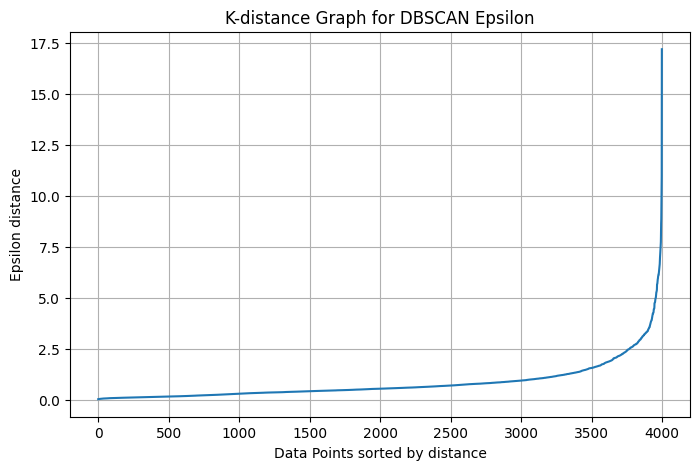

DBSCAN Silhouette Score (excluding noise): 0.2868

DBSCAN Cluster distribution (-1 is noise):
DBSCAN_Cluster
 0    2442
 1    1304
-1     237
 2      16
Name: count, dtype: int64


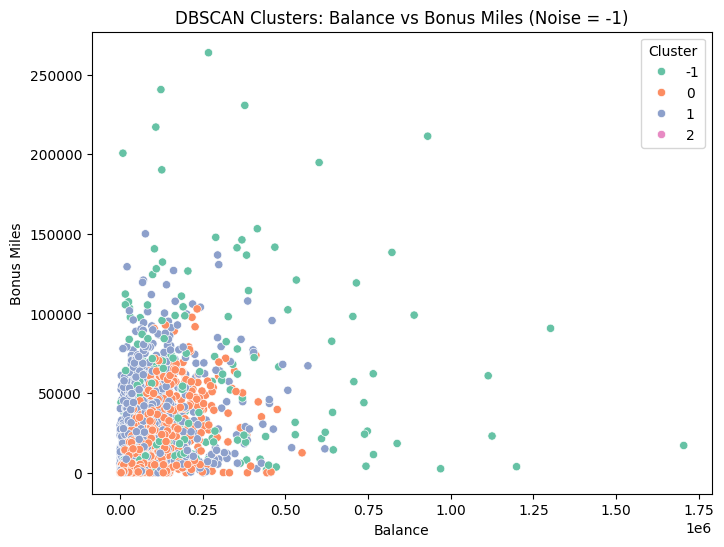

In [ ]:
# Finding optimal Epsilon using NearestNeighbors
neighbors = NearestNeighbors(n_neighbors=10) # 2 * dimension is a good rule of thumb
neighbors_fit = neighbors.fit(df_scaled)
distances, indices = neighbors_fit.kneighbors(df_scaled)

# Sort distances
distances = np.sort(distances[:, 9], axis=0)

# Plot K-distance graph
plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title('K-distance Graph for DBSCAN Epsilon')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('Epsilon distance')
plt.grid(True)
plt.show()

# 2. Fit DBSCAN
dbscan = DBSCAN(eps=2.0, min_samples=10)
dbscan_clusters = dbscan.fit_predict(df_scaled)

df['DBSCAN_Cluster'] = dbscan_clusters

# DBSCAN Evaluation
# DBSCAN often creates a "-1" cluster for noise. We must handle this for the silhouette score.
if len(set(dbscan_clusters)) > 1:
    # Calculate silhouette score only for clustered points (excluding noise)
    mask = dbscan_clusters != -1
    if len(set(dbscan_clusters[mask])) > 1:
        dbscan_silhouette = silhouette_score(df_scaled[mask], dbscan_clusters[mask])
        print(f"DBSCAN Silhouette Score (excluding noise): {dbscan_silhouette:.4f}")
    else:
        print("DBSCAN only found 1 cluster and noise. Adjust parameters.")
else:
    print("DBSCAN found no meaningful clusters. Adjust Epsilon or min_samples.")

# Count of points in each cluster
print("\nDBSCAN Cluster distribution (-1 is noise):")
print(df['DBSCAN_Cluster'].value_counts())

# Visualize DBSCAN Clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Balance'], y=df['Bonus_miles'], hue=df['DBSCAN_Cluster'], palette='Set2')
plt.title('DBSCAN Clusters: Balance vs Bonus Miles (Noise = -1)')
plt.xlabel('Balance')
plt.ylabel('Bonus Miles')
plt.legend(title='Cluster')
plt.show()

#Cluster Analysis & Interpretation

In [ ]:
# Grouping by K-Means cluster to observe average behavior
cluster_summary = df.drop(['DBSCAN_Cluster'], axis=1).groupby('KMeans_Cluster').mean()
display(cluster_summary)

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
KMeans_Cluster,,,,,,,,,,,
0,193291.147436,795.455128,2.179487,1.038462,1.000000,32292.288462,27.628205,5530.230769,16.211538,4688.070513,0.820513
1,122119.899548,151.724887,3.885068,1.002715,1.043439,43772.394570,19.398190,366.520362,1.087783,4777.394570,0.687783
2,59693.586570,112.733010,1.372168,1.031553,1.000809,6311.116505,8.456311,258.830097,0.806634,5744.810680,0.296117
3,36920.458056,96.690413,1.269640,1.006658,1.000000,4897.208389,6.790280,167.861518,0.509321,2236.466711,0.151132


# Interpretation of segments (K-Means)
* Cluster 0:  `More Flyers and High Balance`
~High Balance, High Qual_miles ,and medium/normal credit card usage(cc_2),bonus_trans are high,High Flight_miles_12mo,High Flight_trans_12 and high award represent the core loyal customer base and the trust in the company flights travelling.  strategy :offer premium perks,lounge access,and exclusive upgrades.
* Cluster 1: More credit card usage(cc_1) and More Bonus_miles are visible. we should more focus on increasing the travellers by providing amenties and exciting by offers!
* Cluster 2: Highest days_since_enrolled recorded but the less records as compared to cluster 0&1 . so we should retain the customers by driving offers and coupons and diffrentiating the classes to make them affordable for people,also send welcome offers to regain and increase the engagement.
* Cluster 3: Very least records in every sector , as per the observations we should improvise in every sector for regain the performance and flights performances. Make sure to avail offers and drive welcome offers to provide more engagement,also start reactivation campaings with bonus miles incentives.


## **Evaluation and Performance Metrics**

To evaluate the quality of our clustering, we use the **Silhouette Score**, which measures how similar an object is to its own cluster compared to other clusters. A higher score (closer to 1) indicates better-defined clusters.

Below is the comparative performance and a summary of our findings for both K-Means and DBSCAN.

In [ ]:
import pandas as pd
from IPython.display import display, Markdown

# Ensure the silhouette variables exist from previous cells; fallbacks provided if not.
km_score = round(kmeans_silhouette, 4) if 'kmeans_silhouette' in locals() else "Run K-Means cell first"
db_score = round(dbscan_silhouette, 4) if 'dbscan_silhouette' in locals() else "Run DBSCAN cell first"

# Create a dictionary summarizing the evaluation
evaluation_data = {
    'Algorithm': ['K-Means', 'DBSCAN'],
    'Silhouette Score': [km_score, db_score],
    'Strengths Identified': [
        'Excellent for creating distinct, actionable marketing segments. Forces all data points into a cluster.',
        'Effectively isolates outliers (noise) from the dense, typical customer base without forcing them into a cluster.'
    ],
    'Weaknesses Identified': [
        'Sensitive to the extreme outliers present in the Balance and Bonus_miles columns.',
        'Harder to interpret for standard marketing segmentation since it often lumps the majority of average customers into a single massive cluster.'
    ]
}

# Convert to DataFrame for a clean visual table in Colab
evaluation_df = pd.DataFrame(evaluation_data)

# Display the formatted table
display(Markdown("### **Performance Comparison Table**"))
display(evaluation_df)

### **Performance Comparison Table**

,Algorithm,Silhouette Score,Strengths Identified,Weaknesses Identified
0,K-Means,0.1907,"Excellent for creating distinct, actionable ma...",Sensitive to the extreme outliers present in t...
1,DBSCAN,0.2868,Effectively isolates outliers (noise) from the...,Harder to interpret for standard marketing seg...


### **Conclusion**
**K-Means** provided the most business-interpretable segments by dividing the customer base into clear behavioral tiers (e.g., frequent flyers vs. heavy credit card users). This makes it the ideal model for designing targeted marketing campaigns and loyalty reward tiers.

However, **DBSCAN** proved highly valuable as an anomaly detection tool. By isolating extreme outliers (whale customers or unusual accounts) as "noise", it highlights a specific sub-group of users that may require individualized account management rather than mass marketing.